In [43]:
import pandas as pd
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")

print("Path to dataset files:", path)

os.listdir(path)

Path to dataset files: C:\Users\HopeE\.cache\kagglehub\datasets\suchintikasarkar\sentiment-analysis-for-mental-health\versions\1


['Combined Data.csv']

In [44]:
import os

path_to_csv = os.path.join(path, "Combined Data.csv")

df = pd.read_csv(path_to_csv)

df = df.dropna()

In [45]:
df = df[df['status'].isin(['Normal', 'Depression', 'Anxiety', 'Suicidal', 'Stress'])]

Restructure label into severity level.

In [46]:
df = df[df['status'].isin(['Normal', 'Stress'])]

# Convert status into severity levels
severity_mapping = {
    'Normal': 0,
    'Stress': 1,
}

df['severity'] = df['status'].map(severity_mapping)

In [47]:
df.drop(columns=['status'], inplace=True)

In [48]:
# Rename statement to text
df.rename(columns={'statement': 'text'}, inplace=True)

In [49]:
df.head()

,Unnamed: 0,text,severity
733,733,"Gr gr dreaming of ex crush to be my game, God",0
734,734,wkwkwk what a joke,0
735,735,Leaves are also standby in front of the PC ......,0
736,736,Thank God even though it's just a ride through,0
737,737,wedding teaser concept using the song day6 - o...,0


In [50]:
df['word_len'] = df['text'].str.split().str.len()

df['word_len'].describe()

count    18930.000000
mean        30.548759
std         55.655386
min          1.000000
25%          6.000000
50%         12.000000
75%         26.000000
max       1606.000000
Name: word_len, dtype: float64

In [51]:
df.groupby('severity')['word_len'].agg(['mean', 'median', 'std', 'count'])

,mean,median,std,count
severity,,,,
0,17.246283,10.0,22.769056,16343
1,114.585234,87.0,105.895609,2587


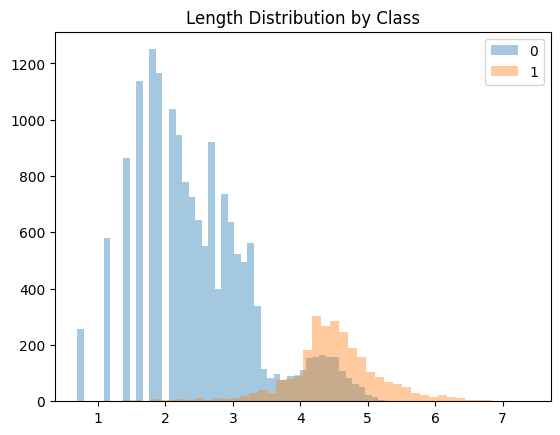

In [52]:
import matplotlib.pyplot as plt
import numpy as np

for label in df['severity'].unique():
    subset = df[df['severity'] == label]
    plt.hist(np.log1p(subset['word_len']), bins=50, alpha=0.4, label=label)

plt.legend()
plt.title('Length Distribution by Class')
plt.show()

## Preprocess Dataset

In [53]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)              # normalize whitespace
    text = re.sub(r'http\S+', '', text)           # remove URLs
    text = re.sub(r'[^\w\s.,!?]', '', text)       # keep emotional punctuation
    return text.strip()

df['clean_text'] = df['text'].astype(str).apply(clean_text)

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['severity'],
    test_size=0.2,
    stratify=df['severity'],
    random_state=42
)

In [55]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9
)

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from lightgbm import LGBMClassifier

models = {
    "logreg": LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ),
    "svm": LinearSVC(class_weight='balanced'),
    "lgbm": LGBMClassifier(
        class_weight='balanced',
        n_estimators=500,
        learning_rate=0.05,
        random_state=42
    )
}

### Evaluation

In [57]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']


results = {}

for name, model in models.items():
    pipeline = make_pipeline(tfidf, model)
    
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )
    
    results[name] = scores

[LightGBM] [Info] Number of positive: 1656, number of negative: 10459
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044754 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 86034
[LightGBM] [Info] Number of data points in the train set: 12115, number of used features: 3077
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


c:\Users\HopeE\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1656, number of negative: 10459
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.041021 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 85054
[LightGBM] [Info] Number of data points in the train set: 12115, number of used features: 3030
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


c:\Users\HopeE\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1656, number of negative: 10459
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.047378 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 85818
[LightGBM] [Info] Number of data points in the train set: 12115, number of used features: 3065
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


c:\Users\HopeE\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1656, number of negative: 10459
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041993 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 85700
[LightGBM] [Info] Number of data points in the train set: 12115, number of used features: 3052
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


c:\Users\HopeE\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1656, number of negative: 10460
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.048799 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 85030
[LightGBM] [Info] Number of data points in the train set: 12116, number of used features: 3028
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


c:\Users\HopeE\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Extract and display results
for name, scores in results.items():
    print(f"Model: {name}")
    for metric in scoring:
        mean_score = scores[f'test_{metric}'].mean()
        std_score = scores[f'test_{metric}'].std()
        print(f"  {metric}: {mean_score:.4f} ± {std_score:.4f}")
    print()

Model: logreg
  accuracy: 0.9383 ± 0.0043
  f1_macro: 0.8861 ± 0.0071
  precision_macro: 0.8472 ± 0.0082
  recall_macro: 0.9450 ± 0.0056

Model: svm
  accuracy: 0.9529 ± 0.0046
  f1_macro: 0.9062 ± 0.0087
  precision_macro: 0.8842 ± 0.0099
  recall_macro: 0.9328 ± 0.0074

Model: lgbm
  accuracy: 0.9523 ± 0.0036
  f1_macro: 0.9027 ± 0.0068
  precision_macro: 0.8886 ± 0.0087
  recall_macro: 0.9185 ± 0.0050



: 

## Using both anxiety n stress as 1 class combined
### Model Evaluation Results

| Model   | Accuracy           | F1 Macro          | Precision Macro    | Recall Macro       |
|---------|-------------------|-------------------|--------------------|--------------------|
| LogReg  | 0.9357 ± 0.0022   | 0.9225 ± 0.0022   | 0.9138 ± 0.0037    | 0.9330 ± 0.0009    |
| SVM     | 0.9465 ± 0.0029   | 0.9346 ± 0.0035   | 0.9309 ± 0.0044    | 0.9386 ± 0.0033    |
| LGBM    | 0.9496 ± 0.0025   | 0.9386 ± 0.0030   | 0.9335 ± 0.0036    | 0.9442 ± 0.0030    |

### Key Observations
- **LGBM** achieves the best overall performance across all metrics.
- **SVM** performs competitively, especially in F1 Macro.
- **LogReg** provides a strong baseline but underperforms relative to the other models.
- Low standard deviations indicate stable cross-validation performance.

--------------------------------------

## Using only anxiety
### Model Evaluation Results

| Model   | Accuracy           | F1 Macro          | Precision Macro    | Recall Macro       |
|---------|-------------------|-------------------|--------------------|--------------------|
| LogReg  | 0.9614 ± 0.0024   | 0.9387 ± 0.0040   | 0.9301 ± 0.0035    | 0.9479 ± 0.0054    |
| SVM     | 0.9741 ± 0.0027   | 0.9578 ± 0.0044   | 0.9589 ± 0.0046    | 0.9567 ± 0.0044    |
| LGBM    | 0.9762 ± 0.0021   | 0.9613 ± 0.0033   | 0.9620 ± 0.0053    | 0.9606 ± 0.0018    |

### Key Observations
- **LGBM** again achieves the best overall performance across all metrics.
- **SVM** is very close to LGBM, particularly strong in precision.
- **LogReg** improves significantly but still trails behind the other models.
- All models show low variance, indicating stable and reliable cross-validation results.
-----------------------
## Using only Stress
### Model Evaluation Results

| Model   | Accuracy           | F1 Macro          | Precision Macro    | Recall Macro       |
|---------|-------------------|-------------------|--------------------|--------------------|
| LogReg  | 0.9383 ± 0.0043   | 0.8861 ± 0.0071   | 0.8472 ± 0.0082    | 0.9450 ± 0.0056    |
| SVM     | 0.9529 ± 0.0046   | 0.9062 ± 0.0087   | 0.8842 ± 0.0099    | 0.9328 ± 0.0074    |
| LGBM    | 0.9523 ± 0.0036   | 0.9027 ± 0.0068   | 0.8886 ± 0.0087    | 0.9185 ± 0.0050    |

### Key Observations
- **SVM** achieves the best overall balance, with the highest accuracy and F1 Macro.
- **LGBM** performs similarly to SVM but slightly lags in recall.
- **LogReg** shows **very high recall** but significantly lower precision, indicating a tendency toward over-predicting positive classes.
- The gap between precision and recall for LogReg suggests potential class imbalance or thresholding effects.
- Slightly higher standard deviations across models indicate more variability compared to previous results.

### Experiment with DistilBERT

In [19]:
def smart_truncate(text, max_len=256):
    words = text.split()
    if len(words) <= max_len:
        return text
    
    half = max_len // 2
    return ' '.join(words[:half] + words[-half:])

df['truncated_text'] = df['clean_text'].apply(lambda x: smart_truncate(x, max_len=256))


In [20]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df[['truncated_text', 'severity']],
    test_size=0.2,
    stratify=df['severity'],
    random_state=42
)

# Add this — rename columns before converting to Dataset
train_df = train_df.rename(columns={"severity": "labels"})
test_df = test_df.rename(columns={"severity": "labels"})

In [21]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

In [22]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch['truncated_text'],
        padding='max_length',
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

Map: 100%|██████████| 4555/4555 [00:00<00:00, 7243.74 examples/s]


In [23]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels= len(df['severity'].unique())
)

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 690.40it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_D

In [24]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from transformers import DataCollatorWithPadding, Trainer

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average='macro'),
        "recall": recall_score(labels, preds, average='macro'),
        "precision": precision_score(labels, preds, average='macro')
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,  # replaces tokenizer
    compute_metrics=compute_metrics
)

In [30]:
print(train_dataset.column_names)   # should show: ['input_ids', 'attention_mask', 'labels']
print(train_dataset[0])             # labels value should be an int (e.g. 0 or 1)

['truncated_text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']
{'labels': tensor(0), 'input_ids': tensor([ 101, 2123, 2102, 2412, 2022, 1999, 1037, 9241, 2043, 2115, 2063, 4439,
        1012,  102,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
       

In [25]:
trainer.train()

c:\Users\HopeE\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Recall,Precision
1,0.126494,0.116443,0.959166,0.949852,0.951975,0.947793
2,0.078258,0.128345,0.964654,0.956481,0.957450,0.955525
3,0.040330,0.146467,0.965971,0.958355,0.962141,0.954766


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.35it/s]
c:\Users\HopeE\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.60it/s]
c:\Users\HopeE\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.20it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3417, training_loss=0.08695260523214722, metrics={'train_runtime': 21213.7413, 'train_samples_per_second': 2.576, 'train_steps_per_second': 0.161, 'total_flos': 3619539200876544.0, 'train_loss': 0.08695260523214722, 'epoch': 3.0})

In [26]:
trainer.evaluate()

c:\Users\HopeE\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.1464666873216629,
 'eval_accuracy': 0.9659714599341384,
 'eval_f1': 0.9583547671869128,
 'eval_recall': 0.9621414132572015,
 'eval_precision': 0.95476595427931,
 'eval_runtime': 386.9016,
 'eval_samples_per_second': 11.773,
 'eval_steps_per_second': 0.737,
 'epoch': 3.0}